# Logistic Regression -Simple model

In [104]:
import pandas as pd
import numpy as np
from category_encoders import OneHotEncoder
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

In [105]:
data=pd.read_csv("Cleaned_HR_Data_Analysis.csv")

In [106]:
data

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,Active,Part-Time,Zone A,Part-Time,Production,Wireless,...,5,4,2,22-Jan-23,Customer Service,External,Passed,1,786.71,63
2841,3423,28-Dec-20,Production Technician I,SVG,Active,Part-Time,Zone A,Full-Time,Production,Engineers,...,4,5,3,14-Oct-22,Technical Skills,External,Completed,1,439.65,19
2842,3424,09-Dec-20,Production Technician I,TNS,Terminated,Contract,Zone B,Temporary,Production,Wireline Construction,...,2,4,5,18-Aug-22,Project Management,Internal,Completed,5,981.13,23
2843,3425,28-May-19,Production Technician I,WBL,Terminated,Contract,Zone B,Full-Time,Production,Aerial,...,5,2,3,19-May-23,Technical Skills,External,Completed,3,184.27,65


In [107]:
data.shape

(2845, 28)

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2845 entries, 0 to 2844
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee ID                 2845 non-null   int64  
 1   StartDate                   2845 non-null   object 
 2   Title                       2845 non-null   object 
 3   BusinessUnit                2845 non-null   object 
 4   EmployeeStatus              2845 non-null   object 
 5   EmployeeType                2845 non-null   object 
 6   PayZone                     2845 non-null   object 
 7   EmployeeClassificationType  2845 non-null   object 
 8   DepartmentType              2845 non-null   object 
 9   Division                    2845 non-null   object 
 10  DOB                         2845 non-null   object 
 11  State                       2845 non-null   object 
 12  GenderCode                  2845 non-null   object 
 13  RaceDesc                    2845 

In [109]:
data.describe(include = 'all')

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
count,2845.000000,2845,2845,2845,2845,2845,2845,2845,2845,2845,...,2845.000000,2845.000000,2845.000000,2845,2845,2845,2845,2845.000000,2845.000000,2845.000000
unique,NaN,1472,32,10,2,3,3,3,6,25,...,NaN,NaN,NaN,366,5,2,4,NaN,NaN,NaN
top,NaN,04-Mar-22,Production Technician I,NEL,Active,Full-Time,Zone A,Temporary,Production,Field Operations,...,NaN,NaN,NaN,08-May-23,Communication Skills,External,Completed,NaN,NaN,NaN
freq,NaN,7,1241,291,2458,997,1013,980,1910,747,...,NaN,NaN,NaN,14,633,1424,737,NaN,NaN,NaN
mean,2470.591916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.941652,3.028471,2.989104,NaN,NaN,NaN,NaN,2.973989,559.278956,49.448506
std,859.450107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.435230,1.410067,1.408816,NaN,NaN,NaN,NaN,1.419682,263.333611,17.689179
min,1001.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,100.040000,17.000000
25%,1736.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,2.000000,328.060000,34.000000
50%,2456.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,3.000000,3.000000,NaN,NaN,NaN,NaN,3.000000,571.810000,49.000000
75%,3197.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,4.000000,4.000000,NaN,NaN,NaN,NaN,4.000000,788.330000,65.000000


In [110]:
data['EmployeeStatus'].value_counts(ascending=True)

EmployeeStatus
Terminated     387
Active        2458
Name: count, dtype: int64

In [111]:
data['EmployeeStatus']=data['EmployeeStatus'].replace({'Active':1,'Terminated':0})

In [112]:
data

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,1,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,1,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,1,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,1,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,1,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,3421,09-May-22,Production Technician I,PL,1,Part-Time,Zone A,Part-Time,Production,Wireless,...,5,4,2,22-Jan-23,Customer Service,External,Passed,1,786.71,63
2841,3423,28-Dec-20,Production Technician I,SVG,1,Part-Time,Zone A,Full-Time,Production,Engineers,...,4,5,3,14-Oct-22,Technical Skills,External,Completed,1,439.65,19
2842,3424,09-Dec-20,Production Technician I,TNS,0,Contract,Zone B,Temporary,Production,Wireline Construction,...,2,4,5,18-Aug-22,Project Management,Internal,Completed,5,981.13,23
2843,3425,28-May-19,Production Technician I,WBL,0,Contract,Zone B,Full-Time,Production,Aerial,...,5,2,3,19-May-23,Technical Skills,External,Completed,3,184.27,65


In [113]:
df= data.drop(columns=['Employee ID','StartDate','Training Date','Training Cost','Training Cost'])

In [114]:
df

,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,DOB,State,...,Current Employee Rating,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Age
0,Production Technician I,CCDR,1,Contract,Zone C,Temporary,Production,Finance & Accounting,07-10-1969,MA,...,4,14-01-2023,1,2,3,Leadership Development,Internal,Failed,2,50
1,Production Technician I,EW,1,Contract,Zone A,Part-Time,Production,Aerial,30-08-1965,MA,...,3,09-09-2022,2,1,5,Customer Service,External,Incomplete,4,58
2,Area Sales Manager,PL,1,Full-Time,Zone B,Part-Time,Sales,General - Sga,06-10-1991,MA,...,4,27-05-2023,1,2,1,Leadership Development,External,Failed,2,27
3,Area Sales Manager,CCDR,1,Contract,Zone A,Full-Time,Sales,Finance & Accounting,04-04-1998,ND,...,2,16-06-2023,5,5,4,Project Management,External,Completed,3,23
4,Area Sales Manager,TNS,1,Contract,Zone A,Temporary,Sales,General - Con,29-08-1969,FL,...,3,25-11-2022,2,5,3,Technical Skills,External,Failed,5,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,Production Technician I,PL,1,Part-Time,Zone A,Part-Time,Production,Wireless,11-06-1959,MA,...,1,15-02-2023,5,4,2,Customer Service,External,Passed,1,63
2841,Production Technician I,SVG,1,Part-Time,Zone A,Full-Time,Production,Engineers,10-06-2001,MA,...,3,19-09-2022,4,5,3,Technical Skills,External,Completed,1,19
2842,Production Technician I,TNS,0,Contract,Zone B,Temporary,Production,Wireline Construction,27-01-1997,MA,...,2,14-03-2023,2,4,5,Project Management,Internal,Completed,5,23
2843,Production Technician I,WBL,0,Contract,Zone B,Full-Time,Production,Aerial,28-05-1954,MA,...,2,25-12-2022,5,2,3,Technical Skills,External,Completed,3,65


In [115]:
test=pd.DataFrame(df.drop(columns=['EmployeeStatus']))

In [116]:
from category_encoders import OneHotEncoder

In [117]:
encoder = OneHotEncoder()
df_encoded = encoder.fit_transform(test)

In [118]:
X=df_encoded

In [119]:
X

,Title_1,Title_2,Title_3,Title_4,Title_5,Title_6,Title_7,Title_8,Title_9,Title_10,...,Training Program Name_4,Training Program Name_5,Training Type_1,Training Type_2,Training Outcome_1,Training Outcome_2,Training Outcome_3,Training Outcome_4,Training Duration(Days),Age
0,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,2,50
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,4,58
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,2,27
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,3,23
4,0,1,0,0,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,5,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2840,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,63
2841,1,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,0,1,19
2842,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,5,23
2843,1,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,0,3,65


In [120]:
y=pd.DataFrame(df['EmployeeStatus'])

In [121]:
y

,EmployeeStatus
0,1
1,1
2,1
3,1
4,1
...,...
2840,1
2841,1
2842,0
2843,0


In [122]:
# Import module to split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [123]:
from sklearn.linear_model import LogisticRegression
logmodel= LogisticRegression()
logmodel.fit(X_train,y_train)

LogisticRegression()

In [124]:
y_pred=logmodel.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [125]:
# calculating accuracy
print('Accuracy' ,(logmodel.score(X_test,y_test)))

Accuracy 0.8330404217926186


In [126]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        91
           1       0.84      0.99      0.91       478

    accuracy                           0.83       569
   macro avg       0.42      0.50      0.45       569
weighted avg       0.70      0.83      0.76       569



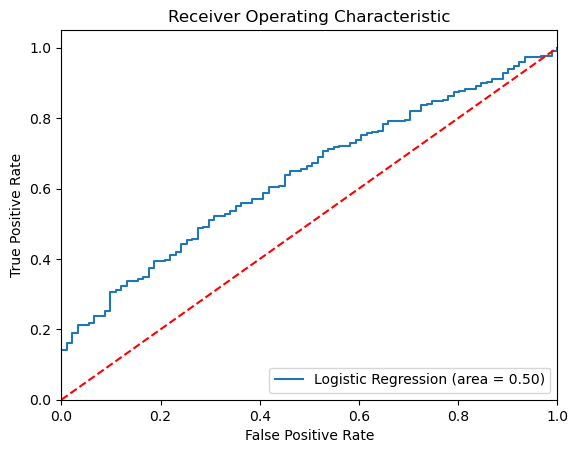

In [127]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logmodel.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logmodel.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# Advanced method- Tree based algorithms

In [6]:
# importing the necessary libraries.
import pandas as pd
import numpy as np

# Visualization tools.
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Preprocessing and Modelling.
from tqdm.notebook import tqdm
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from category_encoders import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import warnings 
warnings.simplefilter("ignore")


In [7]:
data1=pd.read_csv('Cleaned_HR_Data_Analysis.csv')

In [8]:
data1.head()

,Employee ID,StartDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,DepartmentType,Division,...,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,Age
0,3427,20-Sep-19,Production Technician I,CCDR,Active,Contract,Zone C,Temporary,Production,Finance & Accounting,...,1,2,3,15-Jul-23,Leadership Development,Internal,Failed,2,606.11,50
1,3428,11-Feb-23,Production Technician I,EW,Active,Contract,Zone A,Part-Time,Production,Aerial,...,2,1,5,12-Sep-22,Customer Service,External,Incomplete,4,673.02,58
2,3429,10-Dec-18,Area Sales Manager,PL,Active,Full-Time,Zone B,Part-Time,Sales,General - Sga,...,1,2,1,13-Aug-22,Leadership Development,External,Failed,2,413.28,27
3,3430,21-Jun-21,Area Sales Manager,CCDR,Active,Contract,Zone A,Full-Time,Sales,Finance & Accounting,...,5,5,4,15-Dec-22,Project Management,External,Completed,3,663.78,23
4,3431,29-Jun-19,Area Sales Manager,TNS,Active,Contract,Zone A,Temporary,Sales,General - Con,...,2,5,3,13-Jul-23,Technical Skills,External,Failed,5,399.03,50


In [9]:
data1.shape

(2845, 28)

In [10]:
data1.set_index('Employee ID',inplace=True)

In [11]:
data1.shape

(2845, 27)

In [12]:
data1.nunique().sort_values(ascending=False)

Training Cost                 2813
DOB                           2664
StartDate                     1472
Training Date                  366
Survey Date                    366
Age                             66
Title                           32
State                           28
Division                        25
BusinessUnit                    10
DepartmentType                   6
Training Program Name            5
Training Duration(Days)          5
RaceDesc                         5
Current Employee Rating          5
Engagement Score                 5
Satisfaction Score               5
Work-Life Balance Score          5
MaritalDesc                      4
Performance Score                4
Training Outcome                 4
EmployeeClassificationType       3
PayZone                          3
EmployeeType                     3
Training Type                    2
EmployeeStatus                   2
GenderCode                       2
dtype: int64

In [13]:
data1.describe()

,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Duration(Days),Training Cost,Age
count,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000,2845.000000
mean,2.974692,2.941652,3.028471,2.989104,2.973989,559.278956,49.448506
std,1.012610,1.435230,1.410067,1.408816,1.419682,263.333611,17.689179
min,1.000000,1.000000,1.000000,1.000000,1.000000,100.040000,17.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,328.060000,34.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,571.810000,49.000000
75%,3.000000,4.000000,4.000000,4.000000,4.000000,788.330000,65.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,999.970000,82.000000


# EDA on given data

In [14]:
def plot(column, dataframe=data1 ,top_n=5):
       #Plot barchart and piechart side by side
# check to ensure the column is catogorical.
    if dataframe[column].dtypes== 'O':
        dist=dataframe[column].value_counts(normalize=True).head(top_n)
        
# start the ploting the barchart
        fig,(ax0,ax1)=plt.subplots(1,2, figsize=(15,5))
        ax0.bar(dist.index,dist.values)
        ax0.set_xticklabels(rotation=45, labels =dist.index)
        ax0.set_title(f"Bar chart distribution fpr {column}")
        ax0.set_xlabel(column)
        ax0.set_ylabel('Frequency')
    
# ploting pie chart
        ax1.pie(dist, labels=dist.index,autopct="%1.2f%%")
        ax1.set_title(f'Pie Chart Distribution for {column}')
        return fig.show()
    else:
        print('the column given is not a catagorical column')

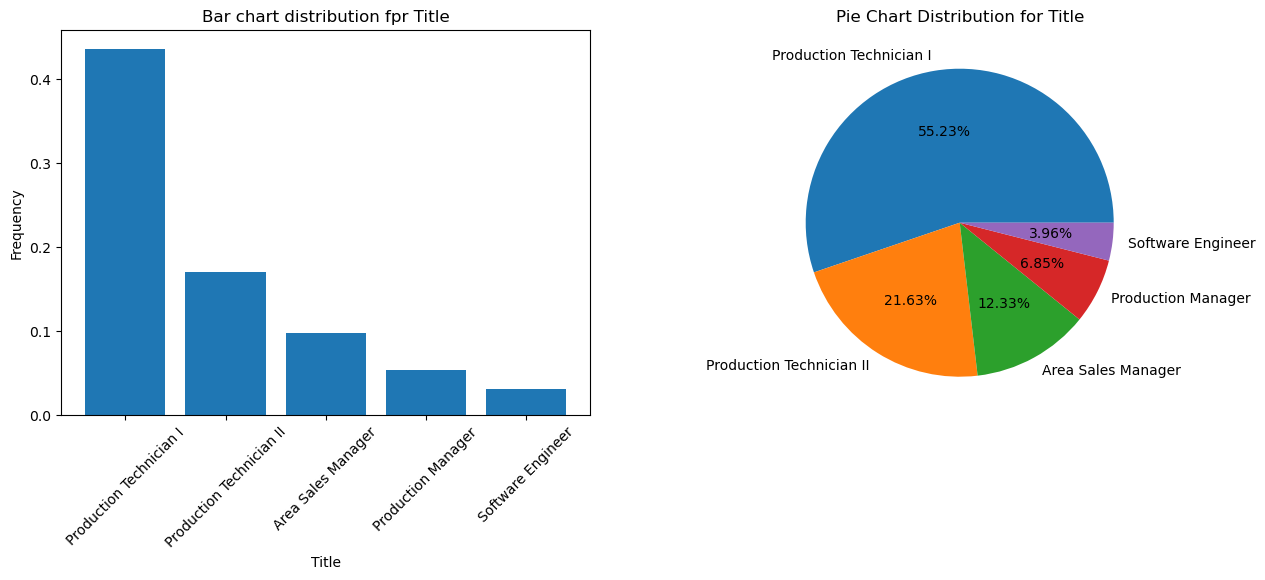

In [15]:
plot('Title')

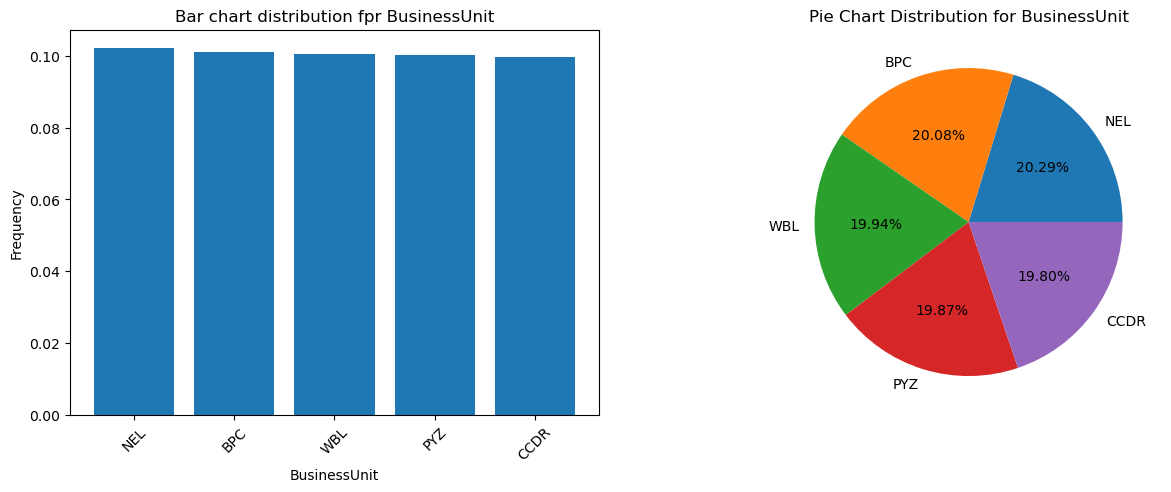

In [16]:
plot("BusinessUnit")

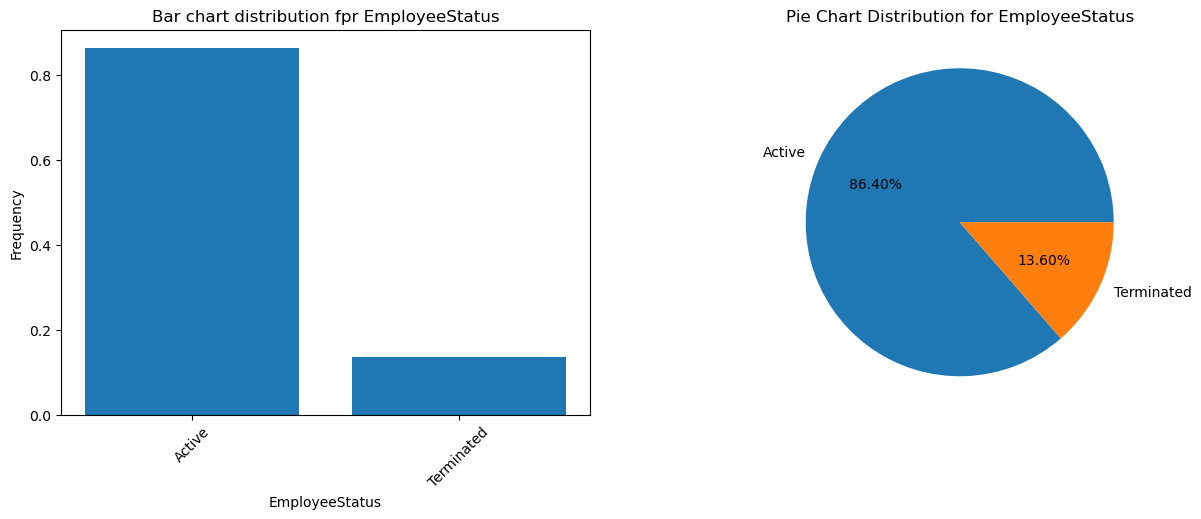

In [17]:
plot("EmployeeStatus")

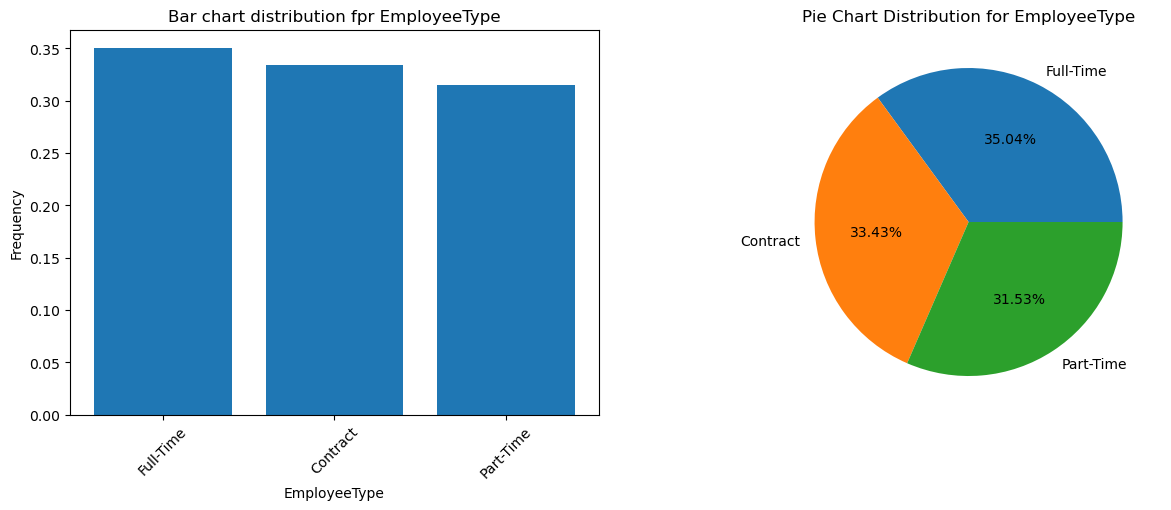

In [18]:
plot("EmployeeType")

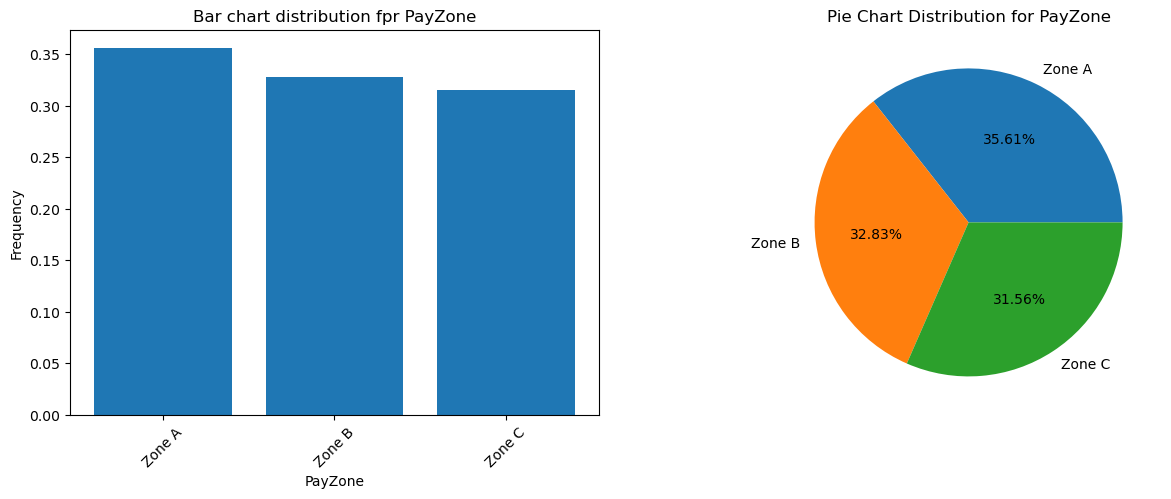

In [19]:
plot("PayZone")

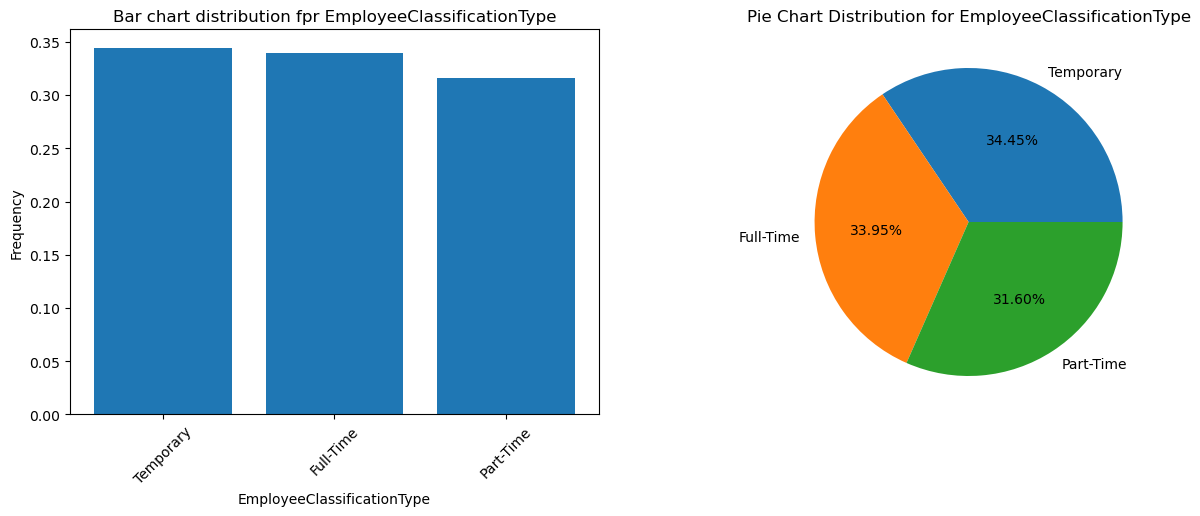

In [20]:
plot("EmployeeClassificationType")

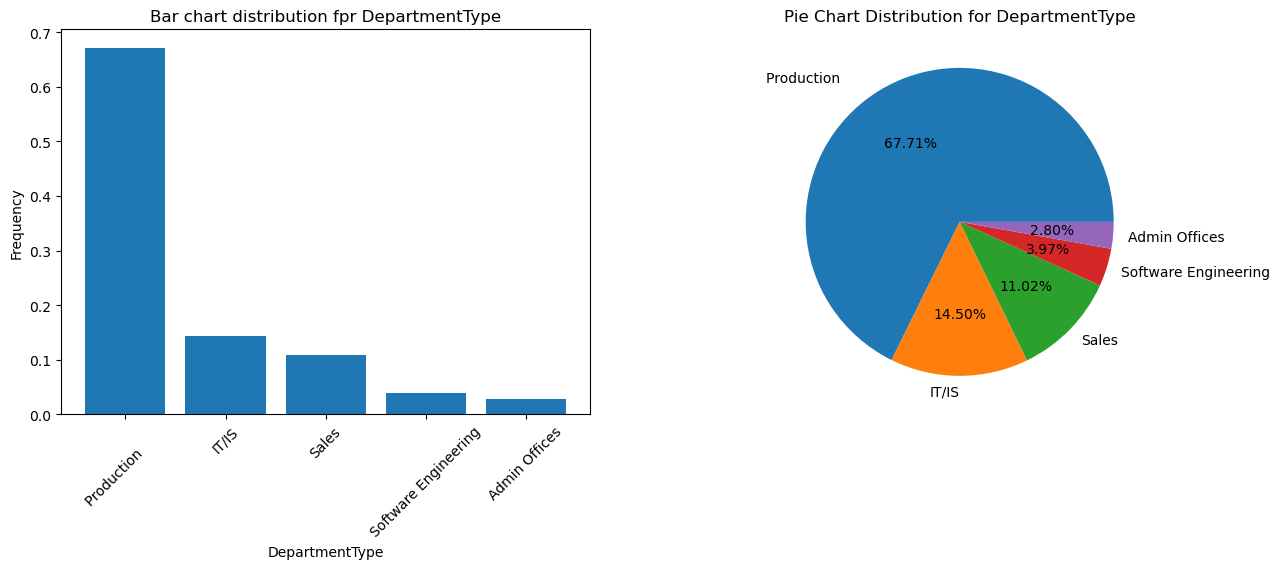

In [21]:
plot("DepartmentType")

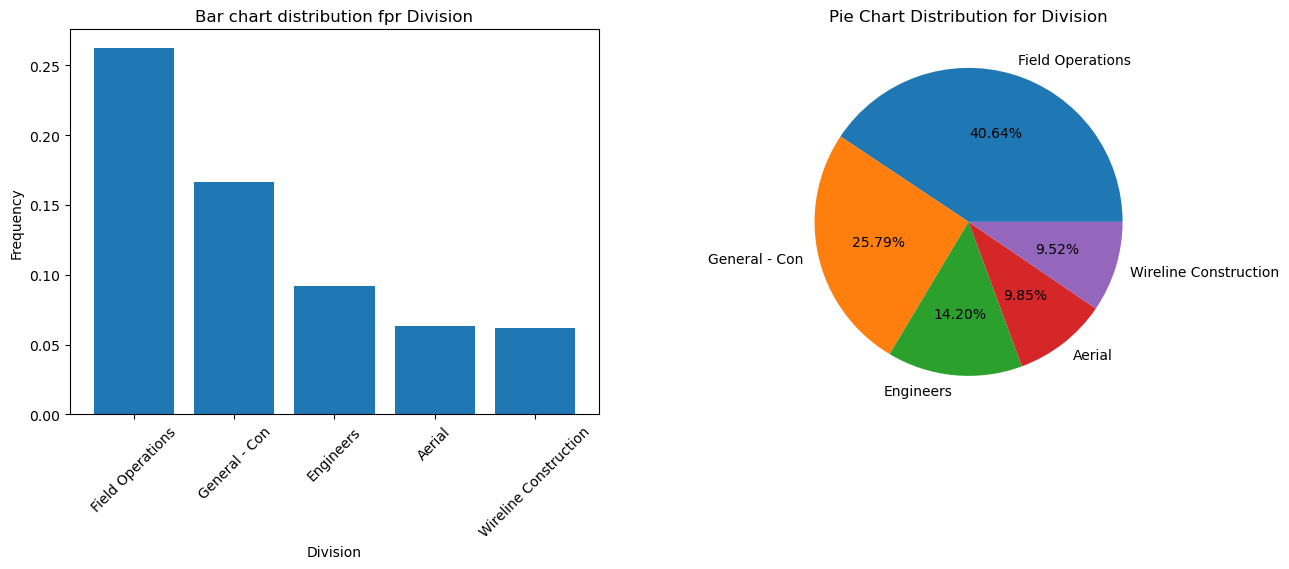

In [22]:
plot("Division")

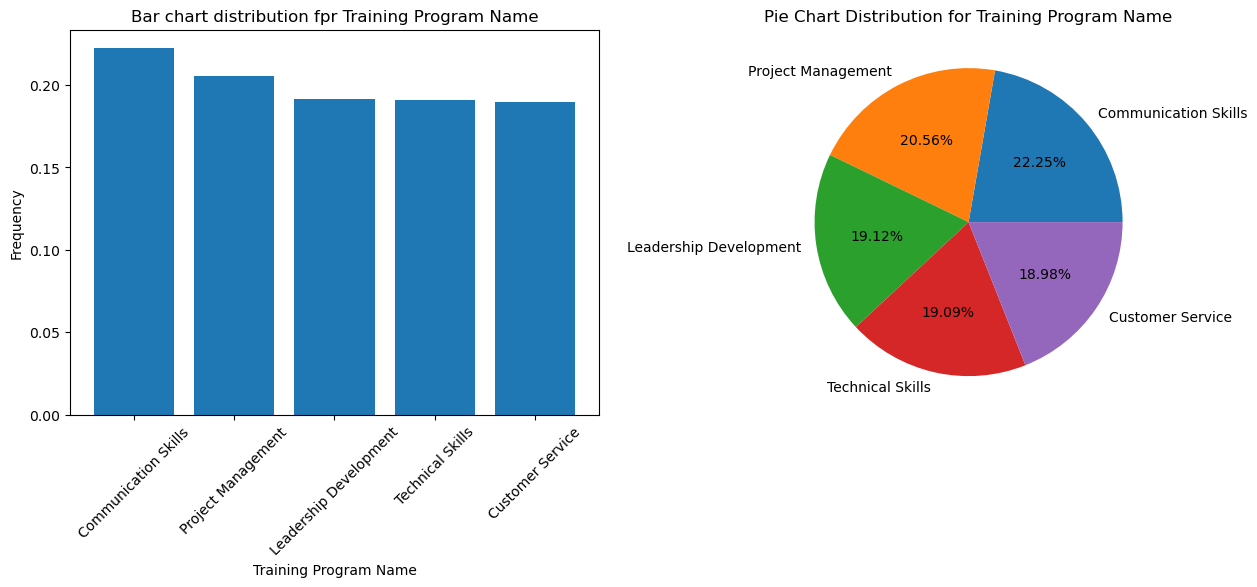

In [23]:
plot("Training Program Name")

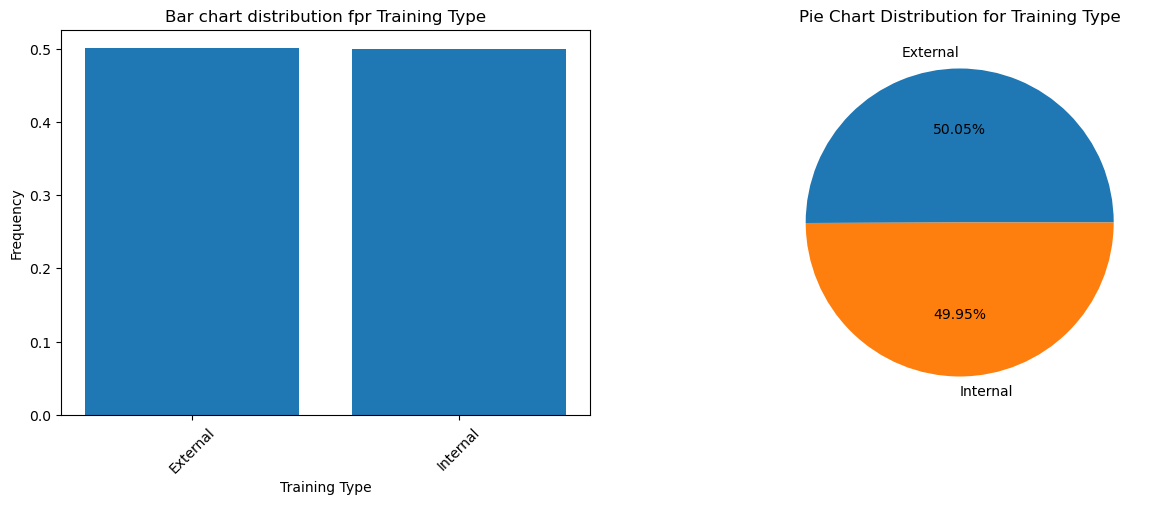

In [24]:
plot("Training Type")

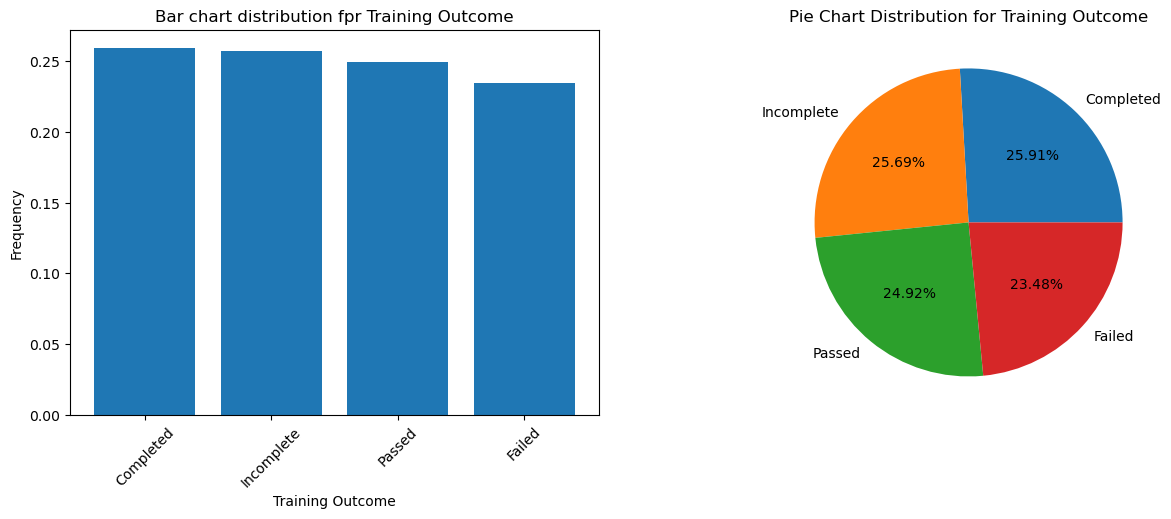

In [25]:
plot("Training Outcome")

<Axes: >

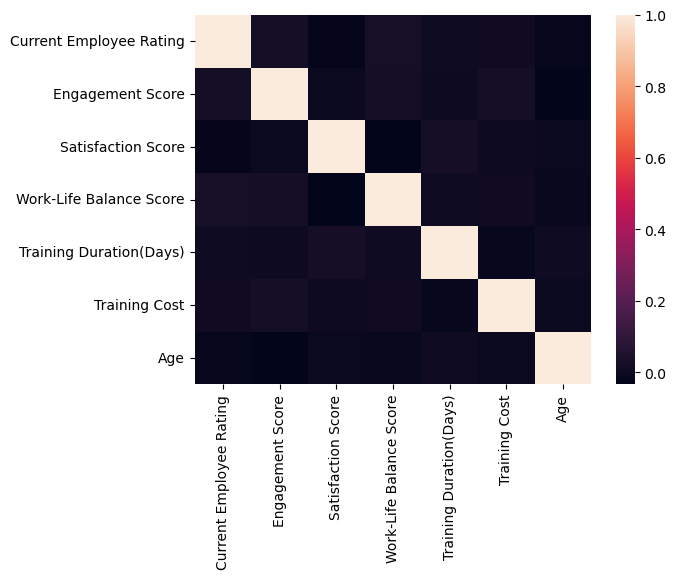

In [26]:
sns.heatmap(data1.select_dtypes('number').corr())

## Bivariate Analysis and Chi-square test.

# Bivariate Analysis

Bivariate analysis refers to the statistical analysis of two variables to determine the empirical relationship between them. The objective is to understand how one variable affects or is related to the other.
This type of analysis is essential in identifying potential relationships or correlations between variables.

# Chi-Square Test

The Chi-Square test is a statisticall test used to determined whether there is a significant association between two categorical variables.
It compares the observed frequencies in a contingency table to the expected frequencies under the null hypotesis(i.e the two variables are independent)

In [27]:
# Creating a function that plot the entered column with the target which is the employeestatus and 
# also return a print statement if there's is relationship between the column and the target
def bivar(column,dataframe=data1):
    """
    Plot a corresponding barchart.

    ------
    Parameter: 
        column: must be categorical
    Return: 
        Barchart
    """
    fig = plt.subplots(figsize=(10, 5))
    #encoding the employeestarus
    dataframe['EmployeeStatus']=dataframe['EmployeeStatus'].replace({'Active':1,'Terminated':0})
    #using groupby method.
    colum_target=dataframe.groupby(column)['EmployeeStatus'].mean().sort_values(ascending=False)
    #plot the barchart
    plt.bar(colum_target.index, colum_target.values)
    plt.xlabel(column)
    plt.xticks(rotation='vertical')
    plt.ylabel('Percentage')
    plt.title(f'probabilityy distribution of employee status based {column}');

In [28]:
def chi(columns, dataframe=data1):
    """
    Get the chi-square test values for all the columns supplied.

    --------
    Parameters: 
        columns: list of categorical columns.
    --------
    Returns:
        p_values and boolean in dataframe.
    """
    p_values=[]
    boolean=[]
    for column in columns:
        crosstab= pd.crosstab(dataframe['EmployeeStatus'],dataframe[column])
        _,p_value, _, _ = chi2_contingency(crosstab)
        p_values.append(p_value)
        # apply condition to check if it is statisically significantly or not
        if p_value <0.05:
            boolean.append(True)
        else:
            boolean.append(False)
#create a datafrme containgn the p_value and boolean
    df=pd.DataFrame({'p_value':p_values,'Significant':boolean},index=columns)
    return df

In [29]:
columns=['Title','BusinessUnit','EmployeeType',
         'PayZone','EmployeeClassificationType','DepartmentType','Division',
         'Training Program Name','Training Type','Training Outcome','Age']
chi(columns,dataframe=data1).sort_values(by='p_value', ascending =False)

,p_value,Significant
Training Type,1.000000e+00,False
Age,8.972959e-01,False
BusinessUnit,8.620481e-01,False
Division,6.947708e-01,False
EmployeeClassificationType,6.634737e-01,False
EmployeeType,4.182481e-01,False
Training Program Name,3.835000e-01,False
PayZone,2.498332e-01,False
Training Outcome,9.109223e-02,False
DepartmentType,5.620640e-14,True


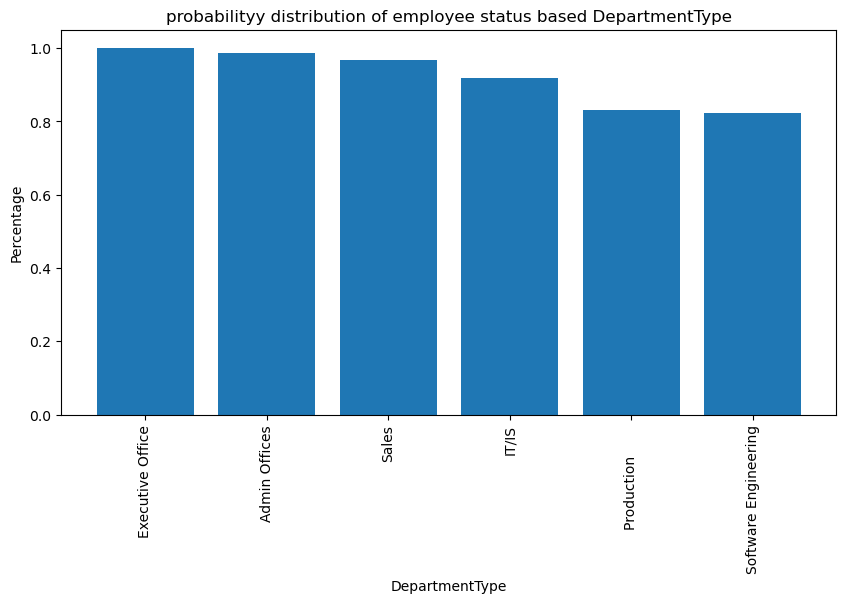

In [30]:
bivar("DepartmentType")

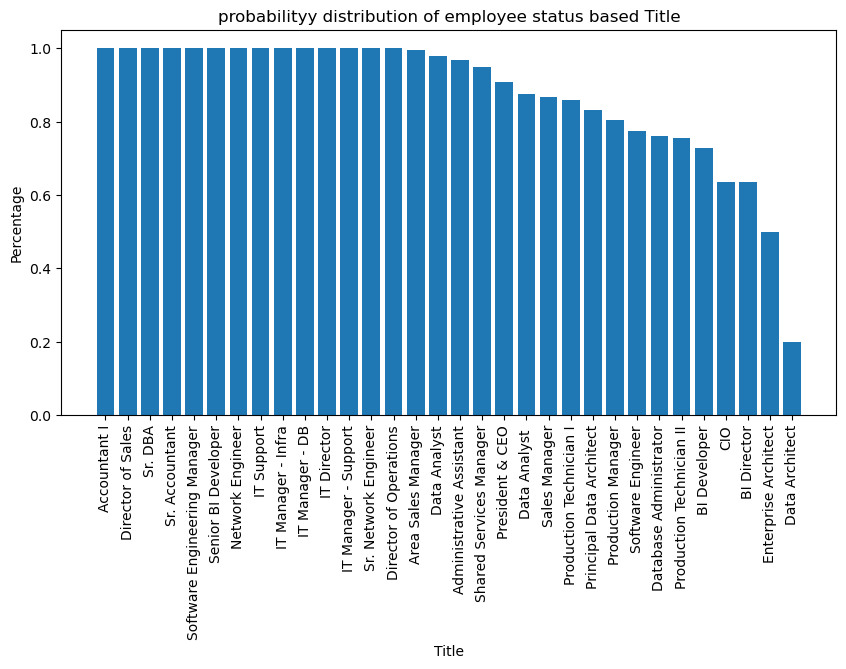

In [31]:
bivar("Title")

# Split the Data

In [35]:
target = "EmployeeStatus"
X = data1.drop(columns=target)
y= data1[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
print(f"X train shape:{X_train.shape}")
print(f"Y train shape: {y_train.shape}")

X train shape:(2276, 26)
Y train shape: (2276,)


In [41]:
# Creating a model fuction that train the dataset and return it accuracy.
def model_accuracy(models, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test):
    """
    This calculate the accuracy of each model and return it corresponding score.

    ----
    Parameter:
        models: list of algorithms
    Return:
        score dataframe.
    """
    # Encoding the y_train and y_test.
    y_train = y_train.replace({"Active": 1, "Terminated": 0})
    y_test = y_test.replace({"Active": 1, "Terminated": 0})
    # Create an empty list to contain the algorithm-name, train_score and test_score
    alg_names= []
    train_scores= []
    test_scores= []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    roc_curves = {}
    
    # Loop through the available algorithms
    for algorithm in tqdm(models, desc="Training"):
        # creating a pipeline.
        model = make_pipeline(
            OrdinalEncoder(),
            StandardScaler(),
            algorithm
        )
        # fit the model on the dataset.
        model.fit(X_train, y_train)
        
        # Get the algorithm name.
        alg_name = list(model.named_steps.keys())[-1]
        alg_names.append(alg_name)
        
        # Perform cross validation.
        kfold = KFold(n_splits=10)
        train_score = np.mean(cross_val_score(model, X_train, y_train, cv=kfold, scoring="accuracy"))
        train_scores.append(train_score)
        
        # Get the predicion on the test dataset.
        y_pred = model.predict(X_test)
        test_score = accuracy_score(y_test, y_pred)
        test_scores.append(test_score)
        precision = precision_score(y_test, y_pred)
        precision_scores.append(precision)
        recall = recall_score(y_test, y_pred)
        recall_scores.append(recall)
        f1 = f1_score(y_test, y_pred)
        f1_scores.append(f1)

    # Compute ROC Curve
        y_probs = model.predict_proba(X_test)[:, 1]  # Get probabilities for class 1
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        roc_curves[alg_name] = (fpr, tpr, roc_auc)
# Plot ROC curve
        plt.plot(fpr, tpr, label=f'{alg_name} (AUC = {roc_auc:.2f})')
        
 # Format and display ROC curve
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid()
    plt.show()    

    # Create DataFrame with results
    score_dataframe = pd.DataFrame({
        "Train Accuracy": train_scores,
        "Test Accuracy": test_scores,
        "Precision": precision_scores,
        "Recall": recall_scores,
        "F1-Score": f1_scores
    }, index=alg_names)
    
    return score_dataframe

Training:   0%|          | 0/4 [00:00<?, ?it/s]

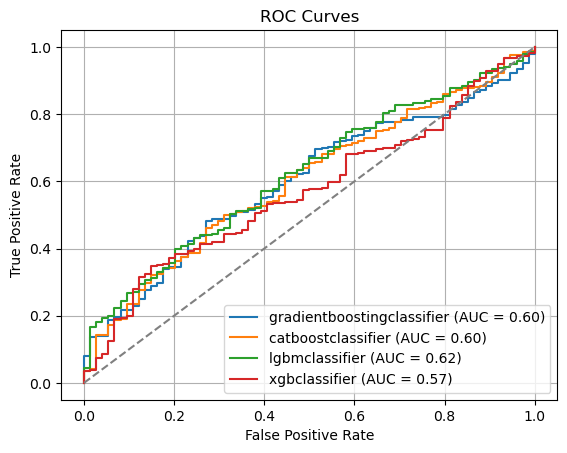

,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
gradientboostingclassifier,0.858503,0.750439,0.868476,0.840404,0.854209
catboostclassifier,0.860694,0.869947,0.869947,1.000000,0.930451
lgbmclassifier,0.847938,0.859402,0.868561,0.987879,0.924386
xgbclassifier,0.843979,0.855888,0.868093,0.983838,0.922348


In [42]:
models = [GradientBoostingClassifier(random_state=42),
         CatBoostClassifier(random_state=42, verbose=0),
         LGBMClassifier(random_state=42, verbose=-1),
         XGBClassifier(random_state=42)]
model_accuracy(models)

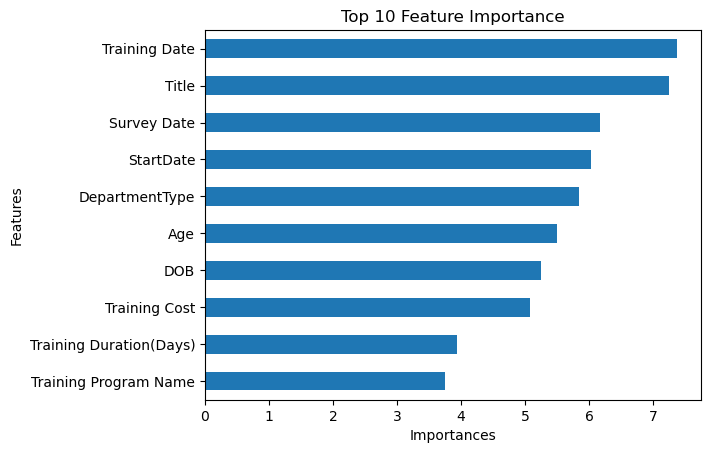

In [45]:
# Getting the feature importances with the best performing model
cat = make_pipeline(
    OrdinalEncoder(),
    StandardScaler(),
    CatBoostClassifier(random_state=42, verbose=0)
)
cat.fit(X_train, y_train)
imp = cat.named_steps["catboostclassifier"].feature_importances_
feat = X_train.columns
feat_imp= pd.Series(imp, index=feat)
feat_imp.sort_values().tail(10).plot(kind="barh")
plt.xlabel("Importances")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance");

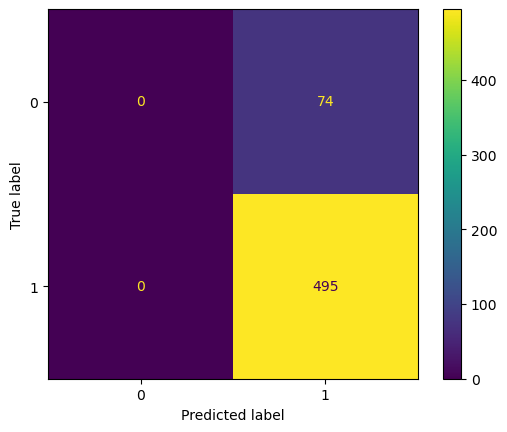

In [46]:
ConfusionMatrixDisplay.from_estimator(cat, X_test, y_test);

Conclusion
The evaluation of multiple boosting-based classifiers—Gradient Boosting, CatBoost, LightGBM, and XGBoost—demonstrated varying levels of performance across accuracy, precision, recall, and F1-score. CatBoost emerged as the best-performing model, achieving the highest test accuracy (86.99%) and perfect recall (1.0), making it highly effective in identifying positive cases. LightGBM followed closely, offering a strong balance between recall and precision, with an F1-score of 92.44%. XGBoost performed similarly to LightGBM, while Gradient Boosting showed signs of overfitting, with a significantly lower test accuracy compared to its training accuracy.

To further enhance model performance, hyperparameter tuning, feature selection, and SHAP-based feature importance analysis can be explored. Additionally, analyzing the confusion matrix can help identify potential improvements, particularly for models with high recall but slightly lower precision. Based on the results, CatBoost or LightGBM would be ideal choices for deployment, given their strong generalization ability and superior test performance.